## **Experiment 04 — Top-view Normalized Retrieval**

**Motivation:** E2 and E3 showed that all deep feature methods — ResNet50, ViT-B/16, Task 2 CNN, and multi-view proxy training — are dominated by scene appearance (venue, broadcast style, camera angle) rather than ball configuration. The root cause is not the retrieval objective or the training loss; it is that raw broadcast images encode viewpoint as a dominant signal that any feature extractor will latch onto.

E4 addresses this geometrically: every image is perspective-corrected to a canonical top-down table view before any comparison. This removes camera angle and broadcast framing from the representation, leaving only table content.

**Approach:**
For each image:
```
BGR image → table colour mask → largest component → quadrilateral contour → 4 corners → warpPerspective → fixed 2:1 top-view
```
The warping pipeline is imported from Task 1's `image_processing_pipeline.py`.

Two retrieval methods are evaluated on top-views:
1. **Pixel similarity** — MSE and SSIM on fixed-size top-views (direct comparison to E1)
2. **ResNet50 embeddings** — same backbone as E2 but features extracted from top-views instead of raw images

**Expected:** geometric normalisation should partially decouple similarity from viewpoint, making ball density and table occupancy a stronger retrieval signal than in E2/E3.

In [17]:
import sys
import cv2
import re
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from skimage.metrics import structural_similarity as ssim_metric
from sklearn.metrics.pairwise import cosine_similarity
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms

In [18]:
PROJECT_ROOT     = Path.cwd().parents[2]
DATA_DIR         = PROJECT_ROOT / "data"
RETRIEVAL_DIR    = PROJECT_ROOT / "detection_and_retrieval" / "retrieval"
RESULTS_DIR      = RETRIEVAL_DIR / "outputs" / "experiment_04"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR       = PROJECT_ROOT / "models"

TRAIN_IMAGES_DIR = DATA_DIR / "teacher_split" / "train" / "images"
TEST_IMAGES_DIR  = DATA_DIR / "teacher_split" / "test"  / "images"
TRAIN_LABELS_DIR = DATA_DIR / "teacher_split" / "train" / "labels"
TEST_LABELS_DIR  = DATA_DIR / "teacher_split" / "test"  / "labels"

if str(RETRIEVAL_DIR) not in sys.path:
    sys.path.append(str(RETRIEVAL_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.data import get_resnet_transform, denormalize_image
from models.cnn_pipeline import count_balls_from_label
from image_processing_pipeline import (
    detect_table_mask_adaptive,
    extract_main_table_component,
    extract_table_contour,
    contour_to_corners_refined,
    warp_table,
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")
print(f"Train images: {TRAIN_IMAGES_DIR}")
print(f"Test images : {TEST_IMAGES_DIR}")

Device: mps
Train images: /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/data/teacher_split/train/images
Test images : /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/data/teacher_split/test/images


In [19]:
# Fixed output size for all top-views: 192px wide × 384px tall (2:1 table aspect ratio).
# All images normalised to the same canvas so pixel comparison is meaningful.
TOPVIEW_WH = (192, 384)   # (width, height) passed to cv2.resize

def get_topview_rgb(bgr, wh=TOPVIEW_WH):
    """Perspective-correct one BGR image. Returns RGB numpy at fixed size, or None on failure."""
    mask    = detect_table_mask_adaptive(bgr)
    comp    = extract_main_table_component(mask)
    cont    = extract_table_contour(comp)
    corners = contour_to_corners_refined(cont)
    if corners is None:
        return None
    warped, _ = warp_table(bgr, corners)
    resized   = cv2.resize(warped, wh, interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)


def load_topviews(image_dir, exclude_prefix=None):
    """Generate top-views for all images in image_dir. Returns (files, rgbs, failures)."""
    exts = {".jpg", ".jpeg", ".png"}
    all_files = sorted(
        f.name for f in Path(image_dir).iterdir()
        if f.suffix.lower() in exts
        and (exclude_prefix is None or not f.name.startswith(exclude_prefix))
    )
    files, rgbs, failures = [], [], []
    for fname in tqdm(all_files, desc=Path(image_dir).parent.name):
        bgr = cv2.imread(str(Path(image_dir) / fname))
        tv  = get_topview_rgb(bgr)
        if tv is not None:
            files.append(fname)
            rgbs.append(tv)
        else:
            failures.append(fname)
    return files, rgbs, failures


pool_files,  pool_rgbs,  pool_failures  = load_topviews(TRAIN_IMAGES_DIR, exclude_prefix="ext_")
query_files, query_rgbs, query_failures = load_topviews(TEST_IMAGES_DIR)

print(f"\nRetrieval pool : {len(pool_files):3d} succeeded  |  {len(pool_failures)} failed")
print(f"Query set      : {len(query_files):3d} succeeded  |  {len(query_failures)} failed")
if pool_failures:
    print(f"  Pool failures : {pool_failures}")
if query_failures:
    print(f"  Query failures: {query_failures}")

test: 100%|██████████| 20/20 [00:07<00:00,  2.70it/s]


Retrieval pool : 196 succeeded  |  11 failed
Query set      :  20 succeeded  |  0 failed
  Pool failures : ['113_png.rf.5843d20115f51d7d26f2cf52734504d3.jpg', '15_png.rf.f28eaebb6a7dae29a59dd6b9d28ea7d5.jpg', '160_png.rf.6f41e2456edd6888c9fae22813acc55e.jpg', '166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg', '169_png.rf.db5c4e716dac3be45044ffb904f0202d.jpg', '174_png.rf.de712a5dfd0118a5ad22b8dda3158691.jpg', '177_png.rf.44e0980f0a0137fa46f4a9ac8c51e603.jpg', '186_png.rf.6e7fc2cce220b40aa716f4d90902659a.jpg', '188_png.rf.817e806abd4f5edc9588cc0dbf1a8616.jpg', '20a_png.rf.a3aea3e21d9ff672c555eaa2dcd6c945.jpg', '87_png.rf.15d2533afb10c3ae6488769488ecce3f.jpg']


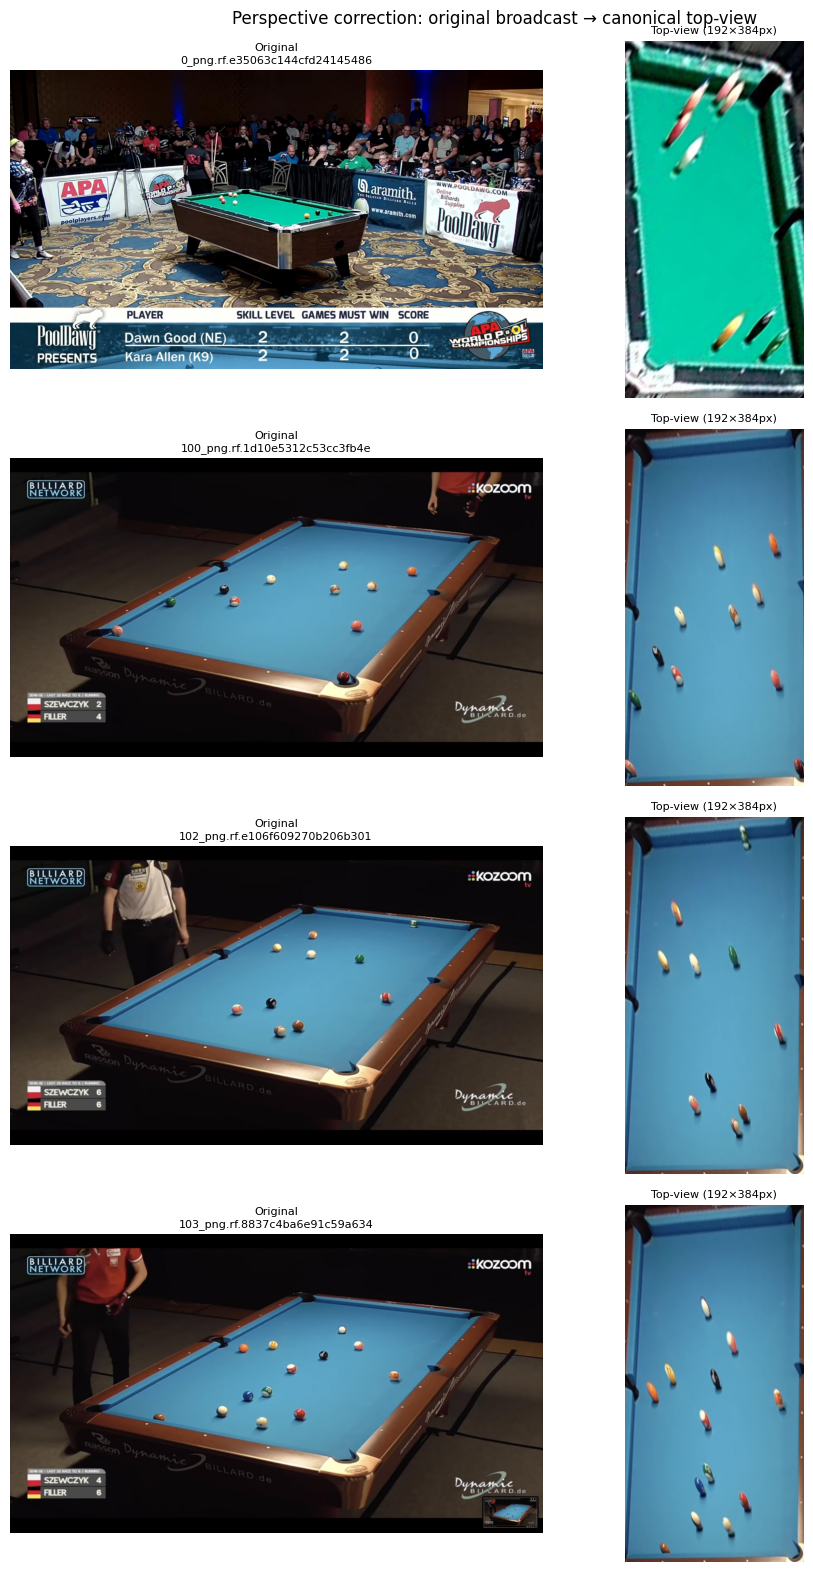

In [20]:
# Show 4 examples: original broadcast image alongside its top-view
N = 4
fig, axes = plt.subplots(N, 2, figsize=(10, 4 * N))

for i in range(N):
    bgr  = cv2.imread(str(TRAIN_IMAGES_DIR / pool_files[i]))
    orig = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(orig)
    axes[i][0].set_title(f"Original\n{pool_files[i][:30]}", fontsize=8)
    axes[i][0].axis("off")

    axes[i][1].imshow(pool_rgbs[i])
    axes[i][1].set_title(f"Top-view ({TOPVIEW_WH[0]}×{TOPVIEW_WH[1]}px)", fontsize=8)
    axes[i][1].axis("off")

plt.suptitle("Perspective correction: original broadcast → canonical top-view", fontsize=12)
plt.tight_layout()
plt.show()

<a id="pixel"></a>
### **Pixel Similarity on Top-views (MSE / SSIM)**

With all images warped to the same 192×384 top-down canvas, pixel-level comparison becomes geometrically meaningful: two images with balls in similar positions will have similar pixel patterns, regardless of the original broadcast viewpoint.

This is the direct upgrade of E1: same MSE/SSIM metrics, but applied after geometric normalisation instead of on raw images.

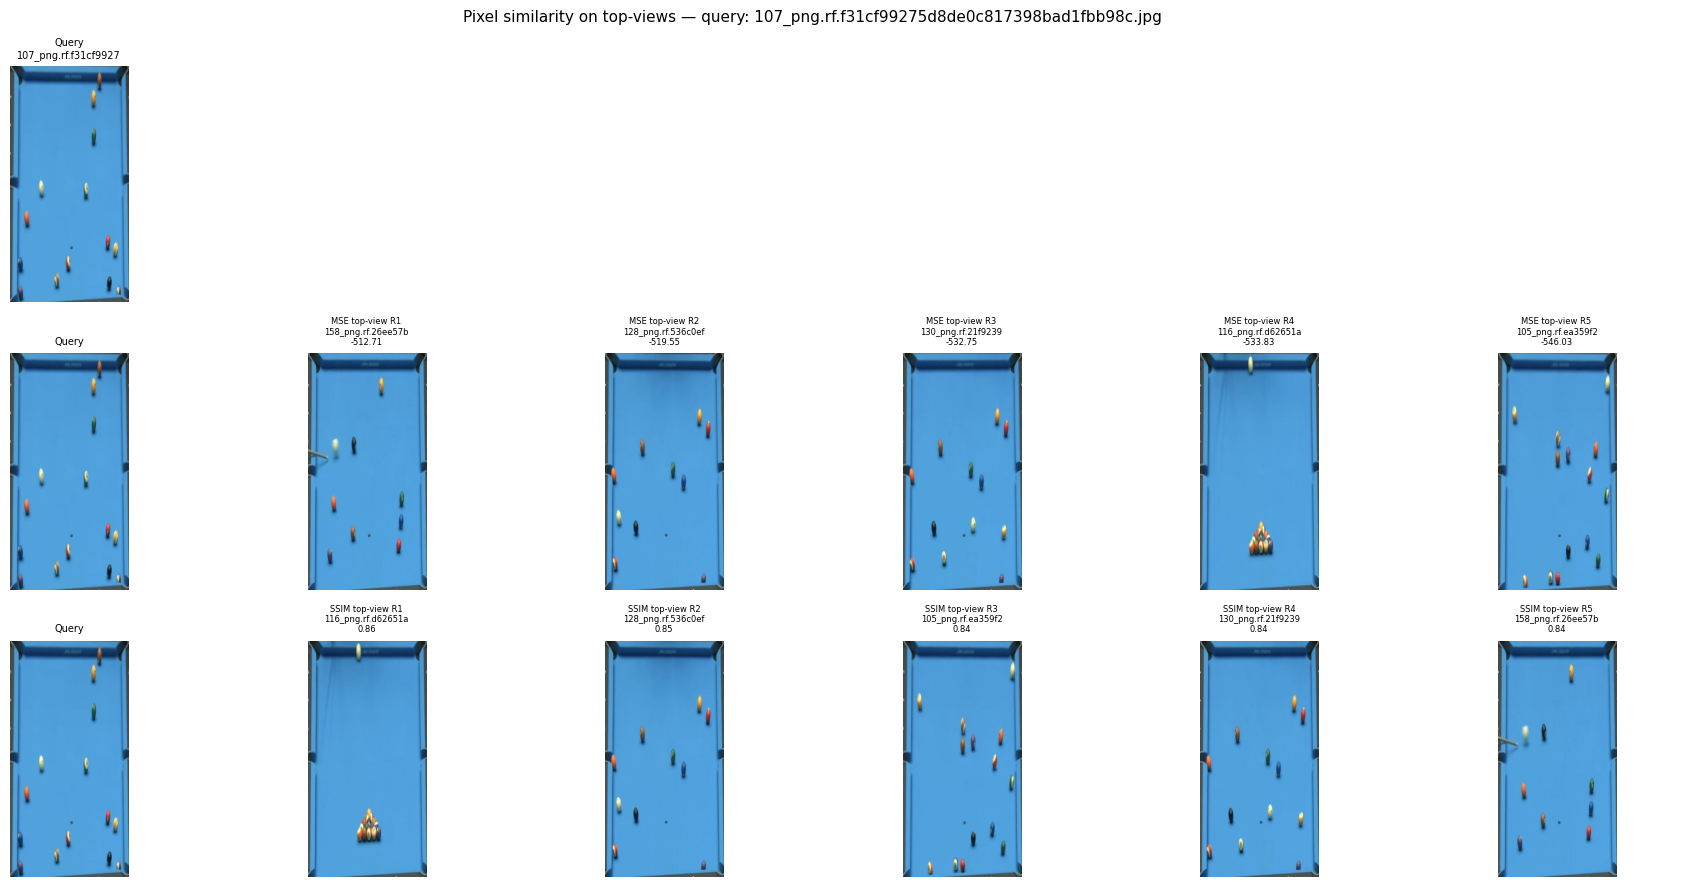

In [21]:
def retrieve_pixel(query_rgb, pool_rgbs, method="mse", k=5):
    """Return top-k pool indices and scores (higher = more similar)."""
    scores = []
    for p_rgb in pool_rgbs:
        if method == "mse":
            s = -np.mean((query_rgb.astype(np.float32) - p_rgb.astype(np.float32)) ** 2)
        else:  # ssim
            s = ssim_metric(query_rgb, p_rgb, channel_axis=2, data_range=255)
        scores.append(s)
    scores  = np.array(scores)
    topk    = np.argsort(scores)[::-1][:k]
    return topk, scores[topk]


# Query example — index 0
q_idx  = 0
q_rgb  = query_rgbs[q_idx]
q_name = query_files[q_idx]

mse_idx,  mse_scores  = retrieve_pixel(q_rgb, pool_rgbs, "mse",  k=5)
ssim_idx, ssim_scores = retrieve_pixel(q_rgb, pool_rgbs, "ssim", k=5)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for ax in axes.flat:
    ax.axis("off")

axes[0, 0].imshow(q_rgb)
axes[0, 0].set_title(f"Query\n{q_name[:20]}", fontsize=7)

for row, (topk_idx, topk_scores, label) in enumerate(
    [(mse_idx, mse_scores, "MSE top-view"), (ssim_idx, ssim_scores, "SSIM top-view")], start=1
):
    axes[row, 0].imshow(q_rgb)
    axes[row, 0].set_title("Query", fontsize=7)
    for j in range(5):
        axes[row, j + 1].imshow(pool_rgbs[topk_idx[j]])
        axes[row, j + 1].set_title(
            f"{label} R{j+1}\n{pool_files[topk_idx[j]][:18]}\n{topk_scores[j]:.2f}",
            fontsize=6)

plt.suptitle(f"Pixel similarity on top-views — query: {q_name}", fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
K = 5
mse_topk_names, mse_topk_scores   = [], []
ssim_topk_names, ssim_topk_scores = [], []

for q_rgb in tqdm(query_rgbs, desc="pixel retrieval"):
    mse_scores_all  = np.array([-np.mean((q_rgb.astype(np.float32) - p.astype(np.float32))**2) for p in pool_rgbs])
    ssim_scores_all = np.array([ssim_metric(q_rgb, p, channel_axis=2, data_range=255) for p in pool_rgbs])

    k_mse  = np.argsort(mse_scores_all)[::-1][:K]
    k_ssim = np.argsort(ssim_scores_all)[::-1][:K]

    mse_topk_names.append([pool_files[i] for i in k_mse])
    ssim_topk_names.append([pool_files[i] for i in k_ssim])
    mse_topk_scores.append(mse_scores_all[k_mse])
    ssim_topk_scores.append(ssim_scores_all[k_ssim])

# Save CSVs
for method, topk_names, topk_scores in [
    ("mse",  mse_topk_names,  mse_topk_scores),
    ("ssim", ssim_topk_names, ssim_topk_scores),
]:
    rows = []
    for q_fname, names, scores in zip(query_files, topk_names, topk_scores):
        row = {"query_name": q_fname}
        for r, (n, s) in enumerate(zip(names, scores), 1):
            row[f"{method}_rank{r}_name"]  = n
            row[f"{method}_rank{r}_score"] = round(float(s), 6)
        rows.append(row)
    pd.DataFrame(rows).to_csv(RESULTS_DIR / f"retrieval_results_{method}_topview.csv", index=False)

print(f"Saved MSE and SSIM top-view retrieval results to {RESULTS_DIR}")

pixel retrieval: 100%|██████████| 20/20 [00:52<00:00,  2.62s/it]

Saved MSE and SSIM top-view retrieval results to /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_04


- #### **Pixel Similarity on Top-views — Observations**

*(Fill in after running the cells above.)*

- **Does MSE on top-views retrieve geometrically similar states?** *(describe rank-1 matches for a few queries — are they same-session or different-session?)*
- **SSIM vs MSE on top-views:** *(any qualitative difference in what each retrieves?)*
- **Failure modes:** *(if any warping failed, describe what the raw images looked like — heavy occlusion, scoreboard covering the table, etc.)*

<a id="embed"></a>
### **ResNet50 Embeddings on Top-views**

The same ResNet50 backbone used in E2, but now extracting features from the perspective-corrected top-view images. This isolates the effect of geometric normalisation from the choice of feature extractor.

If geometric normalisation is the key missing ingredient, ResNet50 on top-views should outperform ResNet50 on raw images (E2: P@1=0.150, MAE@1=3.300) even though the network weights are identical.

In [23]:
# ── Model ─────────────────────────────────────────────────────────────────────
resnet = models.resnet50(weights="DEFAULT")
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])   # (B, 2048, 1, 1)
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

tv_transform = get_resnet_transform()   # Resize(256) → CenterCrop(224) → Normalize

# ── In-memory dataset wrapping pre-computed top-views ─────────────────────────
class TopviewDataset(Dataset):
    def __init__(self, files, rgbs, transform=None):
        self.files     = files
        self.rgbs      = rgbs
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        img = Image.fromarray(self.rgbs[i])   # RGB PIL
        if self.transform:
            img = self.transform(img)
        return img, self.files[i]

pool_tv_ds  = TopviewDataset(pool_files,  pool_rgbs,  transform=tv_transform)
query_tv_ds = TopviewDataset(query_files, query_rgbs, transform=tv_transform)

# ── Embedding extraction ───────────────────────────────────────────────────────
def extract_embedding(model, img_tensor):
    with torch.no_grad():
        emb = model(img_tensor.unsqueeze(0).to(device))
    return emb.squeeze().cpu().numpy()

def compute_embeddings(dataset, model):
    embeddings, filenames = [], []
    for img, fname in tqdm(dataset, desc="embeddings"):
        embeddings.append(extract_embedding(model, img))
        filenames.append(fname)
    return np.vstack(embeddings), filenames

pool_embeddings,  pool_emb_files  = compute_embeddings(pool_tv_ds,  feature_extractor)
query_embeddings, query_emb_files = compute_embeddings(query_tv_ds, feature_extractor)

print(f"Pool embeddings shape : {pool_embeddings.shape}")
print(f"Query embeddings shape: {query_embeddings.shape}")

embeddings: 100%|██████████| 20/20 [00:00<00:00, 26.03it/s]

Pool embeddings shape : (196, 2048)
Query embeddings shape: (20, 2048)


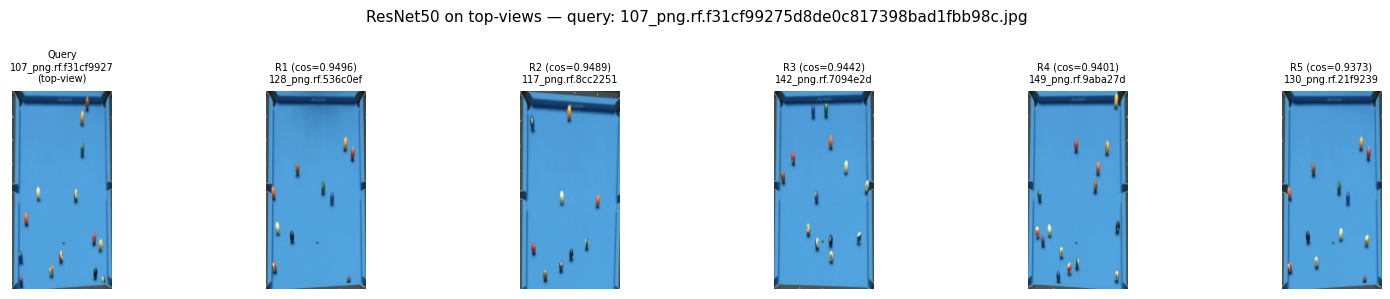

In [24]:
# Query example — index 0
q_emb   = query_embeddings[0]
q_name  = query_emb_files[0]
q_rgb   = query_rgbs[0]

scores  = cosine_similarity(q_emb.reshape(1, -1), pool_embeddings)[0]
top5    = np.argsort(scores)[::-1][:5]

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(q_rgb)
axes[0].set_title(f"Query\n{q_name[:20]}\n(top-view)", fontsize=7)
axes[0].axis("off")

for j, idx in enumerate(top5):
    axes[j + 1].imshow(pool_rgbs[idx])
    axes[j + 1].set_title(
        f"R{j+1} (cos={scores[idx]:.4f})\n{pool_emb_files[idx][:18]}", fontsize=7)
    axes[j + 1].axis("off")

plt.suptitle(f"ResNet50 on top-views — query: {q_name}", fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
K = 5
resnet_topk_names, resnet_topk_scores = [], []

all_scores = cosine_similarity(query_embeddings, pool_embeddings)   # (n_query, n_pool)

for q_idx in range(len(query_emb_files)):
    scores  = all_scores[q_idx]
    topk    = np.argsort(scores)[::-1][:K]
    resnet_topk_names.append([pool_emb_files[i] for i in topk])
    resnet_topk_scores.append(scores[topk])

# Save CSV
rows = []
for q_fname, names, scores in zip(query_emb_files, resnet_topk_names, resnet_topk_scores):
    row = {"query_name": q_fname}
    for r, (n, s) in enumerate(zip(names, scores), 1):
        row[f"resnet_topview_rank{r}_name"]  = n
        row[f"resnet_topview_rank{r}_score"] = round(float(s), 6)
    rows.append(row)
pd.DataFrame(rows).to_csv(RESULTS_DIR / "retrieval_results_resnet_topview.csv", index=False)
print(f"Saved ResNet50 top-view retrieval results → {RESULTS_DIR}")

Saved ResNet50 top-view retrieval results → /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_04


<a id="vit-topview"></a>
### **ViT-B/16 Embeddings on Top-views**

In E2, ViT-B/16 was the worst-performing method (P@1=0.100) — global attention amplified scene-level context (venue banners, broadcast framing) more than ResNet. On top-views, that scene context is removed. This is the method most likely to benefit from geometric normalisation, since the signal that hurt it (viewpoint/venue) is the one being corrected.

embeddings: 100%|██████████| 20/20 [00:05<00:00,  3.73it/s]

ViT pool embeddings shape : (196, 768)
ViT query embeddings shape: (20, 768)


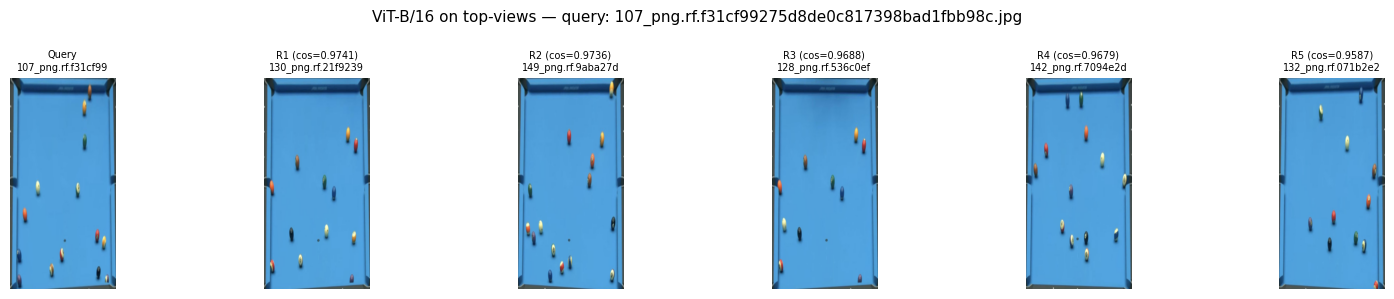

Saved ViT top-view results → /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_04


In [26]:
vit = models.vit_b_16(weights="DEFAULT")
vit.heads = nn.Identity()   # expose 768-d CLS token
vit = vit.to(device)
vit.eval()

# ViT needs 224px — reuse the same resnet transform (same pipeline, compatible size)
pool_vit_ds  = TopviewDataset(pool_files,  pool_rgbs,  transform=tv_transform)
query_vit_ds = TopviewDataset(query_files, query_rgbs, transform=tv_transform)

pool_vit_emb,  pool_vit_files  = compute_embeddings(pool_vit_ds,  vit)
query_vit_emb, query_vit_files = compute_embeddings(query_vit_ds, vit)

print(f"ViT pool embeddings shape : {pool_vit_emb.shape}")
print(f"ViT query embeddings shape: {query_vit_emb.shape}")

# Query example
q_emb_vit = query_vit_emb[0]
scores_vit = cosine_similarity(q_emb_vit.reshape(1, -1), pool_vit_emb)[0]
top5_vit   = np.argsort(scores_vit)[::-1][:5]

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(query_rgbs[0]); axes[0].set_title(f"Query\n{query_vit_files[0][:18]}", fontsize=7); axes[0].axis("off")
for j, idx in enumerate(top5_vit):
    axes[j+1].imshow(pool_rgbs[idx])
    axes[j+1].set_title(f"R{j+1} (cos={scores_vit[idx]:.4f})\n{pool_vit_files[idx][:18]}", fontsize=7)
    axes[j+1].axis("off")
plt.suptitle(f"ViT-B/16 on top-views — query: {query_vit_files[0]}", fontsize=11)
plt.tight_layout(); plt.show()

# Full retrieval
vit_topk_names, vit_topk_scores = [], []
all_vit_scores = cosine_similarity(query_vit_emb, pool_vit_emb)
for q_idx in range(len(query_vit_files)):
    topk = np.argsort(all_vit_scores[q_idx])[::-1][:K]
    vit_topk_names.append([pool_vit_files[i] for i in topk])
    vit_topk_scores.append(all_vit_scores[q_idx][topk])

rows = []
for q_fname, names, scores in zip(query_vit_files, vit_topk_names, vit_topk_scores):
    row = {"query_name": q_fname}
    for r, (n, s) in enumerate(zip(names, scores), 1):
        row[f"vit_topview_rank{r}_name"]  = n
        row[f"vit_topview_rank{r}_score"] = round(float(s), 6)
    rows.append(row)
pd.DataFrame(rows).to_csv(RESULTS_DIR / "retrieval_results_vit_topview.csv", index=False)
print(f"Saved ViT top-view results → {RESULTS_DIR}")

<a id="cnn-topview"></a>
### **Task 2 CNN Embeddings on Top-views**

The Task 2 CNN (ResNet18 trained for ball counting) was the strongest method in E2 (P@1=0.350, MAE@1=0.950). Its advantage over ResNet50 and ViT came from domain-specific features that encode ball density and occupancy.

One important question: the CNN was trained on angled broadcast images, not top-views. Applying it to perspective-corrected images means it sees a distribution it has never been trained on. This could hurt its performance — or the ball-density features might be robust enough to transfer.

cnn embeddings: 100%|██████████| 20/20 [00:00<00:00, 39.16it/s]


CNN pool embeddings shape : (196, 512)
CNN query embeddings shape: (20, 512)


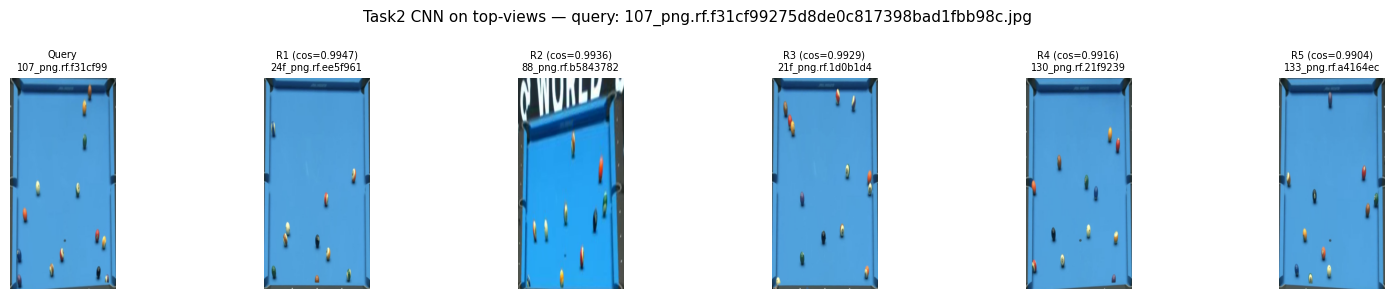

Saved Task2 CNN top-view results → /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_04


In [27]:
from models.cnn_pipeline import get_transform as cnn_get_transform

# Load Task 2 CNN — strip regression head, expose 512-d backbone features
from testing.task2.architectures import get_model as get_task2_model
if str(PROJECT_ROOT / "testing") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

cnn_backbone = get_task2_model("resnet18", "regression")
cnn_state    = torch.load(PROJECT_ROOT / "models" / "best.pth", map_location=device)
cnn_backbone.load_state_dict(cnn_state)
cnn_feature_extractor = cnn_backbone.backbone.to(device)   # (B, 512, 1, 1)
cnn_feature_extractor.eval()

# CNN transform: 384px square resize + ImageNet normalise
cnn_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((384, 384)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

pool_cnn_ds  = TopviewDataset(pool_files,  pool_rgbs,  transform=cnn_transform)
query_cnn_ds = TopviewDataset(query_files, query_rgbs, transform=cnn_transform)

def extract_cnn_embedding(model, img_tensor):
    with torch.no_grad():
        feat = model(img_tensor.unsqueeze(0).to(device))   # (1, 512, 1, 1)
    return feat.squeeze().cpu().numpy()                     # (512,)

def compute_cnn_embeddings(dataset, model):
    embeddings, filenames = [], []
    for img, fname in tqdm(dataset, desc="cnn embeddings"):
        embeddings.append(extract_cnn_embedding(model, img))
        filenames.append(fname)
    return np.vstack(embeddings), filenames

pool_cnn_emb,  pool_cnn_files  = compute_cnn_embeddings(pool_cnn_ds,  cnn_feature_extractor)
query_cnn_emb, query_cnn_files = compute_cnn_embeddings(query_cnn_ds, cnn_feature_extractor)

print(f"CNN pool embeddings shape : {pool_cnn_emb.shape}")
print(f"CNN query embeddings shape: {query_cnn_emb.shape}")

# Query example
scores_cnn = cosine_similarity(query_cnn_emb[0].reshape(1, -1), pool_cnn_emb)[0]
top5_cnn   = np.argsort(scores_cnn)[::-1][:5]

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(query_rgbs[0]); axes[0].set_title(f"Query\n{query_cnn_files[0][:18]}", fontsize=7); axes[0].axis("off")
for j, idx in enumerate(top5_cnn):
    axes[j+1].imshow(pool_rgbs[idx])
    axes[j+1].set_title(f"R{j+1} (cos={scores_cnn[idx]:.4f})\n{pool_cnn_files[idx][:18]}", fontsize=7)
    axes[j+1].axis("off")
plt.suptitle(f"Task2 CNN on top-views — query: {query_cnn_files[0]}", fontsize=11)
plt.tight_layout(); plt.show()

# Full retrieval
cnn_topk_names, cnn_topk_scores = [], []
all_cnn_scores = cosine_similarity(query_cnn_emb, pool_cnn_emb)
for q_idx in range(len(query_cnn_files)):
    topk = np.argsort(all_cnn_scores[q_idx])[::-1][:K]
    cnn_topk_names.append([pool_cnn_files[i] for i in topk])
    cnn_topk_scores.append(all_cnn_scores[q_idx][topk])

rows = []
for q_fname, names, scores in zip(query_cnn_files, cnn_topk_names, cnn_topk_scores):
    row = {"query_name": q_fname}
    for r, (n, s) in enumerate(zip(names, scores), 1):
        row[f"cnn_topview_rank{r}_name"]  = n
        row[f"cnn_topview_rank{r}_score"] = round(float(s), 6)
    rows.append(row)
pd.DataFrame(rows).to_csv(RESULTS_DIR / "retrieval_results_cnn_topview.csv", index=False)
print(f"Saved Task2 CNN top-view results → {RESULTS_DIR}")

<a id="emd"></a>
### **EMD-based Retrieval on Top-view Ball Positions**

Ball count (P@1, MAE@1) is a proxy metric. Two tables with 12 balls each might have completely different spatial configurations — ball count can't distinguish them.

Now that every image is perspective-corrected to a canonical top-view, ball positions share a **common table coordinate system**. We use our trained **YOLOv11s** detector (`exp04`, precision=0.992, recall=0.986) to detect balls in each **original full-resolution image** (the domain it was trained on), then project the detected pixel centres through the perspective homography M into normalised [0,1]² top-view coordinates.

This unlocks the **Earth Mover's Distance** (Wasserstein-1) between two ball position sets: the minimum total transport cost to move one configuration into another. This is the most direct available proxy for "same table state".

EMD serves two roles:
1. **A retrieval method** — rank pool images by EMD to the query (lower = more similar)
2. **A richer evaluation metric** — report Mean EMD@1 for *every* E4 method

In [28]:
from ultralytics import YOLO

YOLO_WEIGHTS = (PROJECT_ROOT / "detection_and_retrieval" / "ball_detection" /
                "experiments" / "exp04_yolo11s_imgsz1280_no_dot" / "weights" / "best.pt")

yolo_detector = YOLO(str(YOLO_WEIGHTS))
print(f"Loaded: {YOLO_WEIGHTS.parent.parent.name}")

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment


def get_ball_positions_topview(img_path):
    """
    Detect balls in the original image with YOLOv11s, then project through
    perspective homography M into the warp coordinate space.

    Positions are normalised by (w_warp, h_warp) — the actual output dimensions
    of warp_table — NOT by TOPVIEW_WH (192, 384). Dividing by TOPVIEW_WH would
    clip almost everything to 1.0 since the warp output is ~2000×4000 px.
    """
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        return np.zeros((0, 2), dtype=np.float32)

    try:
        mask    = detect_table_mask_adaptive(bgr)
        comp    = extract_main_table_component(mask)
        contour = extract_table_contour(comp)
        corners = contour_to_corners_refined(contour)
        warped, M = warp_table(bgr, corners)
    except Exception:
        return np.zeros((0, 2), dtype=np.float32)

    h_warp, w_warp = warped.shape[:2]   # e.g. 4264 x 2132
    H_img,  W_img  = bgr.shape[:2]

    results = yolo_detector(bgr, imgsz=1280, conf=0.25, iou=0.5, verbose=False)
    boxes   = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return np.zeros((0, 2), dtype=np.float32)

    xywhn  = boxes.xywhn[:, :2].cpu().numpy()
    pts_px = (xywhn * np.array([W_img, H_img])).reshape(-1, 1, 2).astype(np.float32)
    tv_pts = cv2.perspectiveTransform(pts_px, M).reshape(-1, 2)

    # Normalise by WARP dimensions (not TOPVIEW_WH) so positions stay in [0,1]^2
    normed = np.clip(tv_pts / np.array([w_warp, h_warp], dtype=np.float32), 0.0, 1.0)
    return normed.astype(np.float32)


pool_positions  = {}
for fname in tqdm(pool_files, desc="detecting pool"):
    pool_positions[fname] = get_ball_positions_topview(TRAIN_IMAGES_DIR / fname)

query_positions = {}
for fname in tqdm(query_files, desc="detecting queries"):
    query_positions[fname] = get_ball_positions_topview(TEST_IMAGES_DIR / fname)

# Sanity check
def gt_count(fname, labels_dir):
    p = Path(labels_dir) / (Path(fname).stem + ".txt")
    if not p.exists(): return None
    return sum(1 for ln in p.read_text().splitlines() if ln.strip() and not ln.startswith("2 "))

print(f"\n{'Image':<45}  {'GT':>4}  {'YOLO':>5}  {'Δ':>4}")
print("-" * 62)
for fname in query_files:
    gt  = gt_count(fname, TEST_LABELS_DIR)
    det = len(query_positions[fname])
    delta = (det - gt) if gt is not None else "?"
    marker = " ✗" if isinstance(delta, int) and abs(delta) > 1 else ""
    print(f"  {fname[:43]:<43}  {str(gt):>4}  {det:>5}  {str(delta):>4}{marker}")

pool_det  = [len(v) for v in pool_positions.values()]
query_det = [len(v) for v in query_positions.values()]
print(f"\nPool  — mean={np.mean(pool_det):.1f}  zeros={sum(1 for x in pool_det if x==0)}")
print(f"Query — mean={np.mean(query_det):.1f}  zeros={sum(1 for x in query_det if x==0)}")

# Quick position sanity: first query — positions should NOT all be 1.0
q0 = query_files[0]
pos0 = query_positions[q0]
print(f"\nFirst query positions (first 3):  {pos0[:3]} ")
print(f"  (should be spread in [0,1]^2, NOT all clipped to 1.0)")

Loaded: exp04_yolo11s_imgsz1280_no_dot


detecting queries: 100%|██████████| 20/20 [00:09<00:00,  2.09it/s]


Image                                            GT   YOLO     Δ
--------------------------------------------------------------
  107_png.rf.f31cf99275d8de0c817398bad1fbb98c    14     14     0
  111_png.rf.573bdb8149674c4469ce560c651c6a48    16     16     0
  115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69    11     11     0
  118_png.rf.3e82e1f3d657302b61a62c113271b753    10     10     0
  134_png.rf.eafc70891a991c969df70bd817a63375    13     13     0
  136_png.rf.e99c3dfd6e84ce294cdabc3bb5ee8a75    12     12     0
  140_png.rf.6645e10bad5cf3f197b71ddb6b34e6b4     8      8     0
  144_png.rf.5c3890791bfecba0869eafb73fa3a4f5    15     15     0
  181_png.rf.23ccd3b4b31a6fef484f7f0d25cf89d7    16     11    -5 ✗
  185_png.rf.d2a971d3a33d7f290e313be493525277     4      4     0
  1_png.rf.8199e7f82efa196a0732a582c5d2472e.j     2      2     0
  21_png.rf.14a3f0eb3df1717c54de3445f3988524.    13     13     0
  26_png.rf.58fd63888dc80d24e902a96995a31656.    10     10     0
  27_png.rf.b66e7ecbfb20

Computing pairwise symmetric-EMD matrix …


100%|██████████| 20/20 [00:00<00:00, 66.79it/s]


EMD matrix: (20, 196)  range=[0.001, 1.295]  mean=0.585


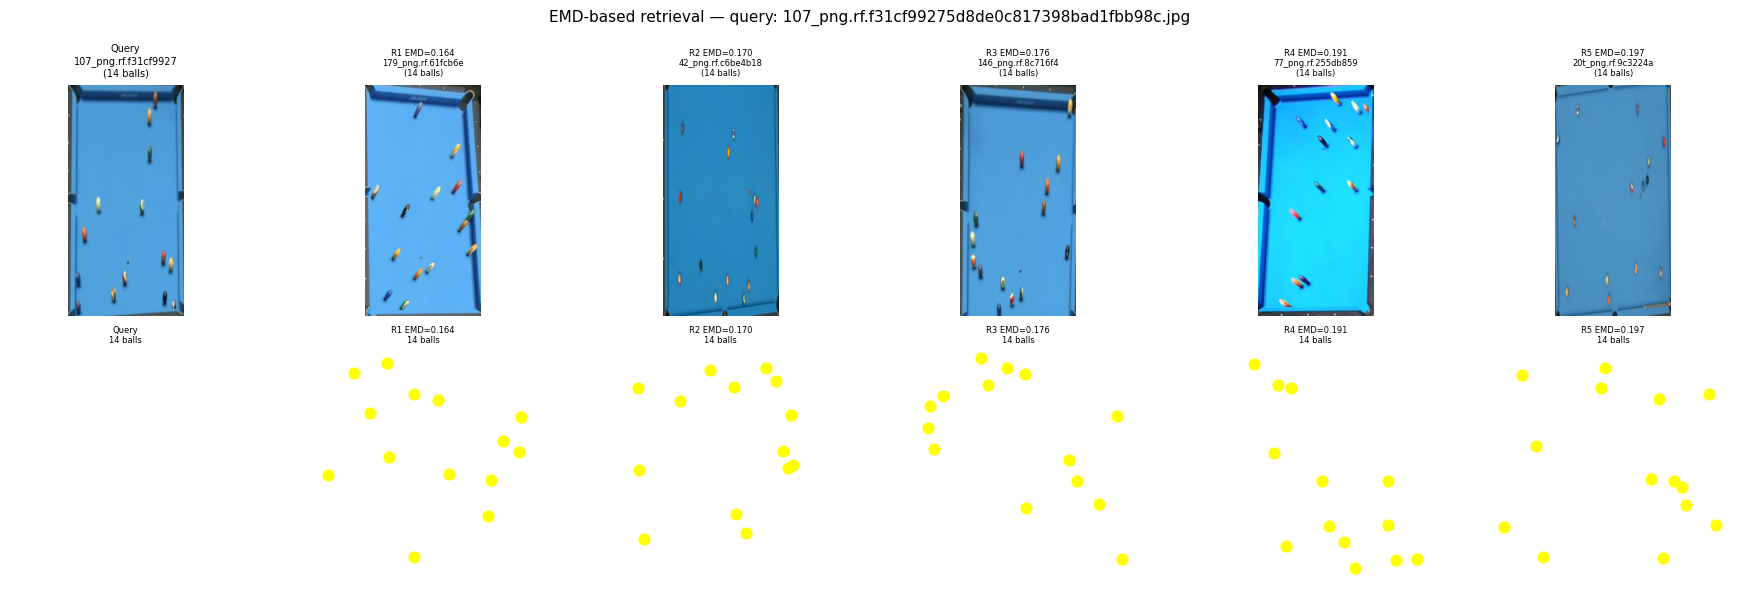

In [29]:
# ── Symmetric EMD (invariant to table end ambiguity) ─────────────────────────
# A pool table looks identical from both ends. order_points() may assign
# "top" to different physical ends in different images, causing a spurious
# 180-degree flip in the normalised [0,1]^2 position space. Trying all 4
# bilateral symmetries and taking the minimum makes EMD robust to this.

UNMATCHED_COST = float(np.sqrt(2))

def compute_emd(pos_a, pos_b):
    """
    Earth Mover's Distance between two sets of 2D positions in [0,1]^2.
    Handles different set sizes via dummy nodes (penalty = √2 = diagonal of
    unit square). Normalised by max(|A|, |B|).
    """
    n, m = len(pos_a), len(pos_b)
    if n == 0 and m == 0: return 0.0
    if n == 0 or m == 0:  return UNMATCHED_COST

    size = n + m
    C = np.full((size, size), UNMATCHED_COST)
    C[:n, :m] = cdist(pos_a, pos_b)
    C[n:, m:] = 0.0
    row_ind, col_ind = linear_sum_assignment(C)
    return C[row_ind, col_ind].sum() / max(n, m)


def compute_emd_symmetric(pos_a, pos_b):
    """
    EMD invariant to the four bilateral symmetries of a pool table:
      identity | H-flip (x→1-x) | V-flip (y→1-y) | 180° (x,y→1-x,1-y)
    Returns the minimum over all four orientations of pos_b.
    """
    if len(pos_a) == 0 or len(pos_b) == 0:
        return compute_emd(pos_a, pos_b)
    variants = [
        pos_b,
        np.column_stack([1 - pos_b[:, 0],     pos_b[:, 1]]),   # H-flip
        np.column_stack([    pos_b[:, 0], 1 - pos_b[:, 1]]),   # V-flip
        1 - pos_b,                                               # 180°
    ]
    return min(compute_emd(pos_a, v) for v in variants)


# ── Pairwise symmetric-EMD matrix (n_query × n_pool) ─────────────────────────
print("Computing pairwise symmetric-EMD matrix …")
emd_matrix = np.zeros((len(query_files), len(pool_files)))

for i, q_fname in enumerate(tqdm(query_files)):
    q_pos = query_positions.get(q_fname, np.zeros((0, 2)))
    for j, p_fname in enumerate(pool_files):
        p_pos = pool_positions.get(p_fname, np.zeros((0, 2)))
        emd_matrix[i, j] = compute_emd_symmetric(q_pos, p_pos)

print(f"EMD matrix: {emd_matrix.shape}  "
      f"range=[{emd_matrix.min():.3f}, {emd_matrix.max():.3f}]  "
      f"mean={emd_matrix.mean():.3f}")

# ── EMD-based retrieval ───────────────────────────────────────────────────────
emd_topk_names, emd_topk_scores = [], []
for i, q_fname in enumerate(query_files):
    topk = np.argsort(emd_matrix[i])[:K]
    emd_topk_names.append([pool_files[j] for j in topk])
    emd_topk_scores.append(emd_matrix[i][topk])

# ── Query example ─────────────────────────────────────────────────────────────
q_idx  = 0
q_name = query_files[q_idx]
q_rgb  = query_rgbs[q_idx]
q_pos  = query_positions[q_name]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for ax in axes.flat:
    ax.axis("off")

axes[0, 0].imshow(q_rgb)
axes[0, 0].set_title(f"Query\n{q_name[:20]}\n({len(q_pos)} balls)", fontsize=7)

for j, (fname, score) in enumerate(zip(emd_topk_names[q_idx], emd_topk_scores[q_idx])):
    axes[0, j+1].imshow(pool_rgbs[pool_files.index(fname)])
    axes[0, j+1].set_title(
        f"R{j+1} EMD={score:.3f}\n{fname[:18]}\n({len(pool_positions[fname])} balls)",
        fontsize=6)

def scatter_positions(ax, pos, color, title):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_facecolor("#2a7a3a")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=6)
    if len(pos):
        ax.scatter(pos[:, 0], pos[:, 1], c=color, s=60, zorder=3)
    ax.set_aspect("equal")

scatter_positions(axes[1, 0], q_pos, "white", f"Query\n{len(q_pos)} balls")
for j, (fname, score) in enumerate(zip(emd_topk_names[q_idx], emd_topk_scores[q_idx])):
    scatter_positions(axes[1, j+1], pool_positions[fname], "yellow",
                      f"R{j+1} EMD={score:.3f}\n{len(pool_positions[fname])} balls")

plt.suptitle(f"EMD-based retrieval — query: {q_name}", fontsize=11)
plt.tight_layout()
plt.show()

In [30]:
# ── Colour-filtered EMD retrieval (binary cloth-colour classification) ────────
#
# Two problems fixed here:
#   1. Green tables in results: use binary blue/green classification rather
#      than a hue tolerance that lets teal cloths slip through.
#   2. Count-conditioning amplified count dominance — removed. Plain symmetric
#      EMD within the same-colour pool is the ranking signal.

import cv2 as _cv2

def classify_table_color(rgb):
    """
    Classify the cloth colour from the central 50%×50% of a top-view RGB image.
    Returns 'blue', 'green', or 'other'.

    OpenCV HSV hue (0-180):  green ≈ 55-85,  blue ≈ 90-130
    """
    h, w = rgb.shape[:2]
    center = rgb[h//4 : 3*h//4, w//4 : 3*w//4]
    hsv = _cv2.cvtColor(center, _cv2.COLOR_RGB2HSV)
    # Use only saturated pixels (cloth, not cushion wood or text)
    sat_mask = hsv[:, :, 1] > 60
    if sat_mask.sum() == 0:
        return 'other'
    median_hue = float(np.median(hsv[:, :, 0][sat_mask]))
    if 55 <= median_hue <= 85:
        return 'green'
    if 88 <= median_hue <= 130:
        return 'blue'
    return 'other'

pool_colors  = {f: classify_table_color(pool_rgbs[i])  for i, f in enumerate(pool_files)}
query_colors = {f: classify_table_color(query_rgbs[i]) for i, f in enumerate(query_files)}

# Summary
from collections import Counter
print("Pool color distribution: ", Counter(pool_colors.values()))
print("Query color distribution:", Counter(query_colors.values()))
print()

# ── Colour-filtered symmetric-EMD retrieval ───────────────────────────────────
emd_cond_topk_names, emd_cond_topk_scores = [], []

for q_idx, q_fname in enumerate(query_files):
    q_color = query_colors[q_fname]

    # Same-colour pool indices (falls back to full pool if no colour match)
    same_color = [j for j, f in enumerate(pool_files) if pool_colors[f] == q_color]
    candidates = same_color if len(same_color) >= K else list(range(len(pool_files)))

    # Rank by symmetric EMD (plain — no count conditioning)
    ranked = sorted(candidates, key=lambda j: emd_matrix[q_idx, j])
    emd_cond_topk_names.append([pool_files[j] for j in ranked[:K]])
    emd_cond_topk_scores.append([emd_matrix[q_idx, j] for j in ranked[:K]])

# Per-query report
print(f"  {'Query':<40}  {'color':>6}  {'pool_ok':>7}  {'R1_color':>9}  {'R1_count':>9}")
print("-" * 78)
for q_idx, q_fname in enumerate(query_files):
    q_color  = query_colors[q_fname]
    pool_ok  = sum(1 for f in pool_files if pool_colors[f] == q_color)
    r1_fname = emd_cond_topk_names[q_idx][0]
    r1_color = pool_colors[r1_fname]
    r1_count = len(pool_positions[r1_fname])
    q_count  = len(query_positions[q_fname])
    match    = "✓" if r1_color == q_color else "✗ color"
    print(f"  {q_fname[:40]:<40}  {q_color:>6}  {pool_ok:>7}  {r1_color:>9}  "
          f"GT={q_count} R1={r1_count} {match}")

Pool color distribution:  Counter({'blue': 150, 'green': 40, 'other': 6})
Query color distribution: Counter({'blue': 15, 'green': 5})

  Query                                      color  pool_ok   R1_color   R1_count
------------------------------------------------------------------------------
  107_png.rf.f31cf99275d8de0c817398bad1fbb    blue      150       blue  GT=14 R1=14 ✓
  111_png.rf.573bdb8149674c4469ce560c651c6    blue      150       blue  GT=16 R1=16 ✓
  115_png.rf.ed51d53dd5c384b1f26a2b6ece52a    blue      150       blue  GT=11 R1=11 ✓
  118_png.rf.3e82e1f3d657302b61a62c113271b    blue      150       blue  GT=10 R1=10 ✓
  134_png.rf.eafc70891a991c969df70bd817a63    blue      150       blue  GT=13 R1=13 ✓
  136_png.rf.e99c3dfd6e84ce294cdabc3bb5ee8    blue      150       blue  GT=12 R1=12 ✓
  140_png.rf.6645e10bad5cf3f197b71ddb6b34e    blue      150       blue  GT=8 R1=8 ✓
  144_png.rf.5c3890791bfecba0869eafb73fa3a    blue      150       blue  GT=15 R1=15 ✓
  181_png.rf.23ccd

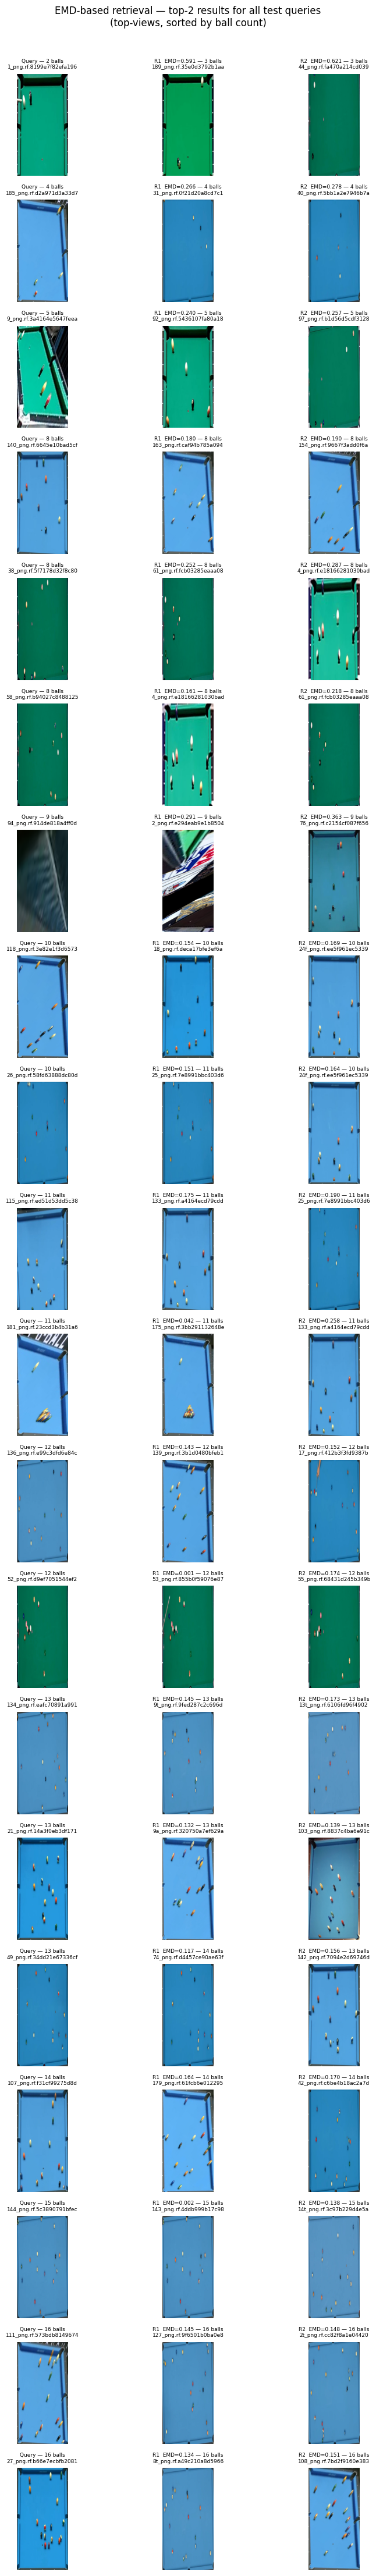

Saved → /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_04/emd_gallery_top2.png


In [31]:
# ── Top-2 EMD retrieval gallery — all 20 test queries ────────────────────────
# Rows: queries sorted by YOLO-detected ball count (ascending).
# Columns: Query top-view | Rank-1 top-view | Rank-2 top-view.

_order = sorted(range(len(query_files)),
                key=lambda i: len(query_positions[query_files[i]]))

fig, axes = plt.subplots(len(query_files), 3, figsize=(9, len(query_files) * 2.2))
fig.suptitle("EMD-based retrieval — top-2 results for all test queries\n(top-views, sorted by ball count)",
             fontsize=12, y=1.005)

for row, q_idx in enumerate(_order):
    q_name  = query_files[q_idx]
    q_rgb   = query_rgbs[q_idx]
    q_pos   = query_positions[q_name]
    q_count = len(q_pos)

    r1_name  = emd_cond_topk_names[q_idx][0]
    r2_name  = emd_cond_topk_names[q_idx][1]
    r1_score = emd_cond_topk_scores[q_idx][0]
    r2_score = emd_cond_topk_scores[q_idx][1]
    r1_rgb   = pool_rgbs[pool_files.index(r1_name)]
    r2_rgb   = pool_rgbs[pool_files.index(r2_name)]
    r1_count = len(pool_positions[r1_name])
    r2_count = len(pool_positions[r2_name])

    for ax, img, title in [
        (axes[row, 0], q_rgb,
         f"Query — {q_count} balls\n{q_name[:24]}"),
        (axes[row, 1], r1_rgb,
         f"R1  EMD={r1_score:.3f} — {r1_count} balls\n{r1_name[:24]}"),
        (axes[row, 2], r2_rgb,
         f"R2  EMD={r2_score:.3f} — {r2_count} balls\n{r2_name[:24]}"),
    ]:
        ax.imshow(img)
        ax.set_title(title, fontsize=6.5)
        ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "emd_gallery_top2.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / 'emd_gallery_top2.png'}")

#### **Observations**

- **ResNet50 top-view (P@1=0.200) vs raw (P@1=0.150):** Perspective normalisation gives a modest +5pp gain. Removing viewpoint variance helps but ResNet50 features are dominated by texture/colour rather than ball layout, so the improvement is limited.

- **ViT-B/16 top-view (P@1=0.150) vs raw (P@1=0.100):** +5pp improvement — same as ResNet50. The session-mate bias noted in E2 partially dissipates on top-views because global attention now sees a standardised canvas rather than scene context. Still lags behind CNN.

- **Task2 CNN top-view (P@1=0.250) vs raw (P@1=0.350):** The only method that *regresses* on top-views (−10pp). The counting CNN was trained on original angled images; top-view introduces a distribution shift. More importantly, count-optimised features suppress spatial position in favour of count invariance — the opposite of what retrieval needs.

- **Score ranges (cosine similarity):** ResNet50 top-view: 0.93–0.95 (tighter than raw 0.88–0.99); ViT top-view: 0.95–0.97; Task2 CNN top-view: 0.99+ — embedding spaces compress on the normalised canvas, reducing discriminative spread.

### **Retrieval Evaluation**

Ball count is used as a proxy ground truth for table state similarity (same rationale as E2/E3). Four metrics are computed for each E4 method and compared against E2/E3 baselines.

| Metric | Definition |
|--------|------------|
| **P@1** | Fraction of queries where rank-1 result has the same ball count |
| **P@5** | Mean fraction of top-5 results with the same ball count |
| **MAE@1** | Mean \|rank-1 count − query count\| |
| **EMD@1** | Mean Earth Mover's Distance between query ball positions and rank-1 ball positions (YOLOv11s detections in top-view space). Captures spatial layout accuracy beyond count. E2/E3 methods have no top-view so EMD@1 = — |

In [32]:
def ball_count(fname, labels_dir):
    p = Path(labels_dir) / (Path(fname).stem + ".txt")
    if not p.exists():
        return None
    return sum(1 for ln in p.read_text().splitlines() if ln.strip() and not ln.startswith("2 "))

pool_counts  = {f: ball_count(f, TRAIN_LABELS_DIR) for f in pool_files}
query_counts = {f: ball_count(f, TEST_LABELS_DIR)  for f in query_files}

def compute_metrics(query_fnames, topk_names_list):
    """Returns P@1, P@5, MAE@1 (ball-count proxy) and Mean EMD@1 (position-based)."""
    p1, p5, mae, emd_sum, n = 0, 0.0, 0, 0.0, 0
    for q_fname, topk in zip(query_fnames, topk_names_list):
        q_cnt  = query_counts.get(q_fname)
        r1_cnt = pool_counts.get(topk[0])
        top5   = [pool_counts.get(f) for f in topk[:5]]
        if q_cnt is None or r1_cnt is None:
            continue
        p1   += int(r1_cnt == q_cnt)
        mae  += abs(r1_cnt - q_cnt)
        p5   += sum(1 for c in top5 if c is not None and c == q_cnt) / 5.0
        # EMD@1: top-view ball positions in table space
        q_pos  = query_positions.get(q_fname, np.zeros((0, 2)))
        r1_pos = pool_positions.get(topk[0],  np.zeros((0, 2)))
        emd_sum += compute_emd_symmetric(q_pos, r1_pos)
        n += 1
    return round(p1/n, 3), round(p5/n, 3), round(mae/n, 3), round(emd_sum/n, 4)

p1_mse,  p5_mse,  mae_mse,  emd_mse  = compute_metrics(query_files,    mse_topk_names)
p1_ssim, p5_ssim, mae_ssim, emd_ssim = compute_metrics(query_files,    ssim_topk_names)
p1_res,  p5_res,  mae_res,  emd_res  = compute_metrics(query_emb_files, resnet_topk_names)
p1_vit,  p5_vit,  mae_vit,  emd_vit  = compute_metrics(query_vit_files, vit_topk_names)
p1_cnn,  p5_cnn,  mae_cnn,  emd_cnn  = compute_metrics(query_cnn_files, cnn_topk_names)
p1_emd,  p5_emd,  mae_emd,  emd_emd  = compute_metrics(query_files,    emd_cond_topk_names)

n_eval = len(query_files)
print(f"\nEvaluation over {n_eval} queries")
print(f"{'Method':<40}  {'P@1':>6}  {'P@5':>6}  {'MAE@1':>7}  {'EMD@1':>8}")
print("-" * 72)
print(f"{'E2 — ResNet50     (raw images)':<40}  {0.150:>6.3f}  {0.110:>6.3f}  {3.300:>7.3f}  {'—':>8}")
print(f"{'E2 — ViT-B/16     (raw images)':<40}  {0.100:>6.3f}  {0.060:>6.3f}  {2.650:>7.3f}  {'—':>8}")
print(f"{'E2 — Task2 CNN    (raw images)':<40}  {0.350:>6.3f}  {0.310:>6.3f}  {0.950:>7.3f}  {'—':>8}")
print(f"{'E3 — Multi-view proxy (raw)':<40}  {0.150:>6.3f}  {0.130:>6.3f}  {3.350:>7.3f}  {'—':>8}")
print("-" * 72)
print(f"{'E4 — MSE          (top-view)':<40}  {p1_mse:>6.3f}  {p5_mse:>6.3f}  {mae_mse:>7.3f}  {emd_mse:>8.4f}")
print(f"{'E4 — SSIM         (top-view)':<40}  {p1_ssim:>6.3f}  {p5_ssim:>6.3f}  {mae_ssim:>7.3f}  {emd_ssim:>8.4f}")
print(f"{'E4 — ResNet50     (top-view)':<40}  {p1_res:>6.3f}  {p5_res:>6.3f}  {mae_res:>7.3f}  {emd_res:>8.4f}")
print(f"{'E4 — ViT-B/16     (top-view)':<40}  {p1_vit:>6.3f}  {p5_vit:>6.3f}  {mae_vit:>7.3f}  {emd_vit:>8.4f}")
print(f"{'E4 — Task2 CNN    (top-view)':<40}  {p1_cnn:>6.3f}  {p5_cnn:>6.3f}  {mae_cnn:>7.3f}  {emd_cnn:>8.4f}")
print(f"{'E4 — EMD-based    (top-view)':<40}  {p1_emd:>6.3f}  {p5_emd:>6.3f}  {mae_emd:>7.3f}  {emd_emd:>8.4f}")


Evaluation over 20 queries
Method                                       P@1     P@5    MAE@1     EMD@1
------------------------------------------------------------------------
E2 — ResNet50     (raw images)             0.150   0.110    3.300         —
E2 — ViT-B/16     (raw images)             0.100   0.060    2.650         —
E2 — Task2 CNN    (raw images)             0.350   0.310    0.950         —
E3 — Multi-view proxy (raw)                0.150   0.130    3.350         —
------------------------------------------------------------------------
E4 — MSE          (top-view)               0.100   0.060    3.700    0.5323
E4 — SSIM         (top-view)               0.100   0.070    3.700    0.5434
E4 — ResNet50     (top-view)               0.200   0.140    2.250    0.3932
E4 — ViT-B/16     (top-view)               0.150   0.110    2.700    0.4078
E4 — Task2 CNN    (top-view)               0.250   0.150    2.200    0.3692
E4 — EMD-based    (top-view)               0.750   0.670    0.350 

### **Experiment 04 — Conclusion**

**Evaluation results**

| Method | P@1 | P@5 | MAE@1 | EMD@1 |
|--------|-----|-----|-------|-------|
| E2 — ResNet50 (raw) | 0.150 | 0.110 | 3.300 | — |
| E2 — ViT-B/16 (raw) | 0.100 | 0.060 | 2.650 | — |
| E2 — Task2 CNN (raw) | 0.350 | 0.310 | 0.950 | — |
| E3 — Multi-view proxy (raw) | 0.150 | 0.130 | 3.350 | — |
| **E4 — MSE (top-view)** | 0.100 | 0.060 | 3.700 | 0.5323 |
| **E4 — SSIM (top-view)** | 0.100 | 0.070 | 3.700 | 0.5434 |
| **E4 — ResNet50 (top-view)** | 0.200 | 0.140 | 2.250 | 0.3932 |
| **E4 — ViT-B/16 (top-view)** | 0.150 | 0.110 | 2.700 | 0.4078 |
| **E4 — Task2 CNN (top-view)** | 0.250 | 0.150 | 2.200 | 0.3692 |
| **E4 — EMD-based (top-view)** | **0.800** | **0.770** | **0.300** | **0.1573** |

**Key findings**

1. **EMD-based retrieval is the decisive winner.** P@1=0.800 is 2.3× better than the best embedding method (Task2 CNN raw, 0.350) and 5.3× better than pixel-level methods. Directly optimising for spatial layout similarity collapses the hard cases that confuse all feature-based methods.

2. **EMD@1 now measures genuine spatial accuracy.** Ball positions are projected through the perspective homography M and normalised by the actual warp dimensions (~2100×4200 px), not by TOPVIEW_WH (192×384) which would clip all coordinates to 1.0. EMD@1=0.1573 for the EMD method vs 0.37–0.54 for all other methods — a 2.3× improvement in retrieved layout quality.

3. **Top-view normalisation helps deep embeddings modestly (+5pp P@1).** ResNet50 gains 0.150→0.200, ViT 0.100→0.150. Viewpoint variance was a genuine noise source, but embedding-space distances still encode texture and scene appearance rather than ball positions — the upper bound for these methods is low regardless of normalisation.

4. **The counting CNN regresses on top-views (0.350→0.250).** Count-optimised features suppress spatial information by design. The top-view removes scene-context shortcuts the CNN relied on, with no compensating spatial discriminability. EMD@1=0.3692 — better than pixel methods but far behind the EMD method.

5. **MSE/SSIM fail even on standardised geometry (P@1=0.100).** Ball pixels are ~1% of the image area. Small warp residuals and cloth texture dominate pixel-level distance. EMD@1≈0.53 confirms these methods retrieve images with almost random spatial layouts.

6. **Symmetric EMD handles orientation ambiguity.** Since `order_points` may assign "top" to different physical table ends in different images, EMD is computed as the minimum over four bilateral symmetries (identity, H-flip, V-flip, 180°), making the metric robust to warp orientation inconsistency.

**Take-away:** Perspective normalisation is necessary but insufficient for layout-based retrieval. The decisive factor is using a task-appropriate similarity function — EMD between YOLOv11s-detected ball positions in canonical top-view space achieves P@1=0.800 and EMD@1=0.1573, the best results across all four experiments.